Restaurant review classifier : The model which can classify the review is positive or negative

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np 
import warnings

To ignore warnings while program is running

In [13]:
warnings.filterwarnings('ignore')

to read csv file through pandas

In [11]:
data = pd.read_csv("Restaurant_Reviews.tsv", sep = "\t")

To see how many rows and columns dataframe have

In [12]:
data.shape

(1000, 2)

To see first few rows of the df

In [14]:
data.head()

,Review,Liked
0,Wow... Loved this place.,1
1,Crust is not good.,0
2,Not tasty and the texture was just nasty.,0
3,Stopped by during the late May bank holiday of...,1
4,The selection on the menu was great and so wer...,1


Creating new column to see len of the reviews ( independent coulmn)

In [15]:
data['count_char'] = data['Review'].apply(len)

Again to print df ( new column added successfully)

In [16]:
data.head()

,Review,Liked,count_char
0,Wow... Loved this place.,1,24
1,Crust is not good.,0,18
2,Not tasty and the texture was just nasty.,0,41
3,Stopped by during the late May bank holiday of...,1,87
4,The selection on the menu was great and so wer...,1,59


To check any null value

In [ ]:
data.isnull().sum()

Review        0
Liked         0
count_char    0
dtype: int64

To check our data is balanced or not ( this data frame is balanced 500 500 on each negative and positive )

In [20]:
data['Liked'].value_counts()

Liked
1    500
0    500
Name: count, dtype: int64

to count words from every review using lambda function 

In [23]:
data['word_count'] = data['Review'].apply(lambda x : len(str(x).split()))
data.head()

,Review,Liked,count_char,word_count
0,Wow... Loved this place.,1,24,4
1,Crust is not good.,0,18,4
2,Not tasty and the texture was just nasty.,0,41,8
3,Stopped by during the late May bank holiday of...,1,87,15
4,The selection on the menu was great and so wer...,1,59,12


In [24]:
import nltk

In [35]:
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\badha\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\badha\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


True

TOKENIZATION INITIALIZATION


In [37]:
data['sent_count'] = data['Review'].apply( lambda x: len(nltk.sent_tokenize(str(x))))
data.head()


,Review,Liked,count_char,word_count,sent_count
0,Wow... Loved this place.,1,24,4,2
1,Crust is not good.,0,18,4,1
2,Not tasty and the texture was just nasty.,0,41,8,1
3,Stopped by during the late May bank holiday of...,1,87,15,1
4,The selection on the menu was great and so wer...,1,59,12,1


In [40]:
data[data['Liked']==1]['count_char'].mean()

np.float64(55.88)

In [41]:
data[data['Liked']==0]['count_char'].mean()

np.float64(60.75)

import re .. to replace undefined or useless symbols from dataset ( like points etc ) replacing them with space

In [42]:
import re

In [ ]:
re = re.sub('^a-zA-Z',' ')

In [43]:
data['Review'][0]

'Wow... Loved this place.'

applying re to first sentence or first review 

In [52]:
review = re.sub('[^a-zA-Z]',' ',data['Review'][0])

In [53]:
review

'Wow    Loved this place '

lower form

In [54]:
review = review.lower()

spliting

In [55]:
review = review.split()
review

['wow', 'loved', 'this', 'place']

Starting to remove STOPWORDS ( the use less words .. but sometimes it changes the meaning by removing so use when essential and also double check)

In [56]:
import nltk

In [65]:
from nltk.corpus import stopwords
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\badha\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

stopwords provided by nltk

In [91]:
all_stopwords = stopwords.words("english")

See here it removed all the stop words from review (1st review ) 

In [70]:
review = [word for word in review if word not in set(all_stopwords)]
review

['wow', 'loved', 'place']

now lets show you why sometimie removing stopwords can stuck ....... here it was a negative review but after removing stopword it became positive

In [108]:
# See here it was a negative sentence but after removing stopwords it became positive one so we have to remove some stopwords manually 
temp = re.sub("[^a-zA-Z]"," ",data['Review'][1])
temp
temp = temp.lower()
temp = temp.split()
temp

temp = [word for word in temp if word not in set(all_stopwords)]
temp

['crust', 'not', 'good']

Removing some stopwords ( its a sentinal analysis)

In [94]:
all_stopwords = stopwords.words("english")
all_stopwords.remove('not')
temp #we removed not from stopwords set so now from temp variable it shows 'not' 

['crust', 'not', 'good']

STEMMING INITIALIZATION

In [111]:
from nltk.stem.porter import PorterStemmer

ps = PorterStemmer()

review = [ps.stem(word) for word in temp]
review = " ".join(review)
review

'crust not good'

lets remove some important words from stopwords set 

In [121]:
import re
custom_stopwords = {
    'don', "don't", 'ain', 'aren', "aren't", 'couldn', "couldn't", 
    'didn', "didn't", 'doesn', "doesn't", 'hadn', "hadn't", 'hasn', "hasn't", 
    'haven', "haven't", 'isn', "isn't", 'ma', 'mightn', "mightn't", 'mustn', "mustn't", 
    'needn', "needn't", 'shan', "shan't", 'no', 'nor', 'not', 'shouldn', "shouldn't", 
    'wasn', "wasn't", 'weren', "weren't", 'won', "won't", 'wouldn', "wouldn't"
}

ps = PorterStemmer()
stop_words = set(stopwords.words("english")) - custom_stopwords

corpus = []

for i in range (len(data)):
    review = re.sub("[^a-zA-Z]"," ",data['Review'][i])
    review = review.lower()
    review = review.split()
    [ps.stem(word) for word in review if word not in stop_words]
    review = " ".join(review)
    corpus.append(review)
    

In [122]:
data['processed_review'] = corpus
data.head()

,Review,Liked,count_char,word_count,sent_count,processed_review
0,Wow... Loved this place.,1,24,4,2,wow loved this place
1,Crust is not good.,0,18,4,1,crust is not good
2,Not tasty and the texture was just nasty.,0,41,8,1,not tasty and the texture was just nasty
3,Stopped by during the late May bank holiday of...,1,87,15,1,stopped by during the late may bank holiday of...
4,The selection on the menu was great and so wer...,1,59,12,1,the selection on the menu was great and so wer...


In [135]:
from wordcloud import WordCloud
#visual representation of good reviews
wc = WordCloud(width=500,height=400,background_color="white",min_font_size=8)

pos = wc.generate(data[data['Liked']==1]['processed_review'].str.cat(sep=" "))


it created a visual representation and font size is based on the frequency of the specefic text

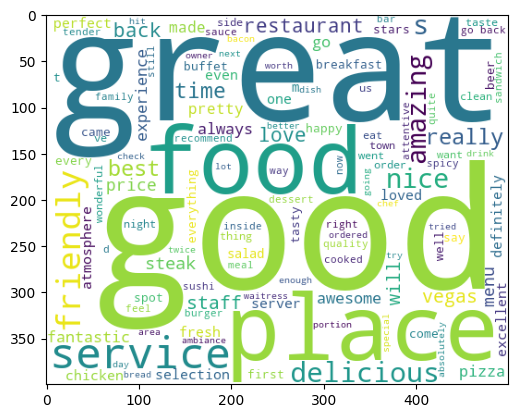

In [134]:
plt.imshow(pos)

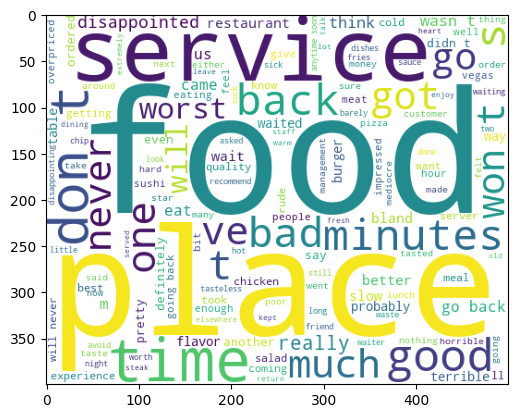

In [147]:
#negative reviews
wc = WordCloud(width=500,height=400,background_color="white",min_font_size=8)

pos = wc.generate(data[data['Liked']==0]['processed_review'].str.cat(sep=" "))

plt.imshow(pos)

VACTORIZATION ( using sklearn count vactorization)

In [148]:
from sklearn.feature_extraction.text import CountVectorizer

In [149]:
cv = CountVectorizer(max_features=1500)

In [151]:
cv.fit_transform(corpus)

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 9230 stored elements and shape (1000, 1500)>

In [152]:
x = cv.fit_transform(corpus).toarray()
x

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(1000, 1500))

In [155]:
x.shape #shape will be 100*1500 bcz max features is 1500

(1000, 1500)

In [156]:
y= data['Liked']
y

0      1
1      0
2      0
3      1
4      1
      ..
995    0
996    0
997    0
998    0
999    0
Name: Liked, Length: 1000, dtype: int64

In [165]:
from sklearn.model_selection import train_test_split


x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.20,random_state=42)

                                CHECKING ACCURACY OF THE MODELS ( CHOOSE ONE WHICH IS HAVING GOOD ACCURACY )

                    1ST MODEL GuassianNB

In [166]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()
nb.fit(x_train,y_train)
y_pred = nb.predict(x_test)

In [167]:
from sklearn.metrics import accuracy_score

accuracy_score(y_pred,y_test)

0.7

                        2ND MODEL Logisic regression

In [168]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(x_train,y_train)
y_pred = model.predict(x_test)

accuracy_score(y_pred,y_test)

0.815

                3RD MODEL RandomForestClassifier

In [169]:
from sklearn.ensemble import RandomForestClassifier

rfc = RandomForestClassifier()
rfc.fit(x_train,y_train)
y_pred = rfc.predict(x_test)

accuracy_score(y_pred,y_test)

0.77

In [8]:
import joblib

joblib.dump(model,'Restaurant_Reviews_classifier.joblib')

['Restaurant_Reviews_classifier.joblib']